# <center>Student Performance Analysis 

## Project Question:
**What factors are associated with student academic performance?**

## Guiding Questions:
1. Does study time relate to final grades?
2. Does attendance affect performance?
3. Does previous academic performance predict final grades?
4. Are there differences between schools?
5. Does family background appear related to performance?
6. Which variables have the strongest relationship with final grade?

The steps this notebooks will follow are:
1. Data loading
2. Inspection
3. Cleaning
4. Exploratory data analysis
5. Visualizations
6. Conclusions and recommendations

In [41]:
# load the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [42]:
# load the mathematics csv
math_df = pd.read_csv("student-mat.csv", sep = ';') # the csv is not separated by a comma, but by a semicolon. specify to avoid problems
math_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [43]:
# load the portuguese csv
port_df = pd.read_csv("student-por.csv", sep = ';')
port_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [44]:
# Open and read the txt file
with open('student.txt', 'r', encoding='utf-8') as file:
    content = file.read()

# Print the text to the VS Code terminal
print(content)


# Attributes for both student-mat.csv (Math course) and student-por.csv (Portuguese language course) datasets:
1 school - student's school (binary: "GP" - Gabriel Pereira or "MS" - Mousinho da Silveira)
2 sex - student's sex (binary: "F" - female or "M" - male)
3 age - student's age (numeric: from 15 to 22)
4 address - student's home address type (binary: "U" - urban or "R" - rural)
5 famsize - family size (binary: "LE3" - less or equal to 3 or "GT3" - greater than 3)
6 Pstatus - parent's cohabitation status (binary: "T" - living together or "A" - apart)
7 Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
8 Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
9 Mjob - mother's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or 

### Miscellaneous Info
**Nominal data** - there's no inherent ranking between the data. eg:   
- Gender: male vs female, mother vs father  
- Eye color: Brown, Blue, Green  
- Marital status: Single, Married, Divorced  
- Blood type: A, B, AB, O  

**Ordinal data** - has categories where the order or ranking matters, but the mathematical distance between the categories is unknown or unequal. eg:    
- Customer satisfaction: Unsatisfied, Neutral, Satisfied
- Education level: High School, Bachelor's, Master's, PhD
- T-shirt size: Small, Medium, Large


## Data Inspection

In [45]:
print(f"Mathematics CSV Columns: \n{math_df.columns}")
print(f"Portuguese CSV Columns: \n{port_df.columns}")


Mathematics CSV Columns: 
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
Portuguese CSV Columns: 
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [46]:
print(math_df.shape)
print(port_df.shape)

(395, 33)
(649, 33)


In [47]:
# get a quick and comprehensive summary of the Maths DataFrame
print(math_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [48]:
# # get a quick and comprehensive summary of the Portuguese DataFrame
print(port_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [49]:
# identify missing values in percentage form - Maths
math_df.isnull().mean().sort_values()*100

school        0.0
G1            0.0
absences      0.0
health        0.0
Walc          0.0
Dalc          0.0
goout         0.0
freetime      0.0
famrel        0.0
romantic      0.0
internet      0.0
higher        0.0
nursery       0.0
activities    0.0
paid          0.0
G2            0.0
famsup        0.0
failures      0.0
studytime     0.0
traveltime    0.0
guardian      0.0
reason        0.0
Fjob          0.0
Mjob          0.0
Fedu          0.0
Medu          0.0
Pstatus       0.0
famsize       0.0
address       0.0
age           0.0
sex           0.0
schoolsup     0.0
G3            0.0
dtype: float64

In [50]:
# identify missing values in percentage form - Portuguese
port_df.isnull().mean().sort_values()*100

school        0.0
G1            0.0
absences      0.0
health        0.0
Walc          0.0
Dalc          0.0
goout         0.0
freetime      0.0
famrel        0.0
romantic      0.0
internet      0.0
higher        0.0
nursery       0.0
activities    0.0
paid          0.0
G2            0.0
famsup        0.0
failures      0.0
studytime     0.0
traveltime    0.0
guardian      0.0
reason        0.0
Fjob          0.0
Mjob          0.0
Fedu          0.0
Medu          0.0
Pstatus       0.0
famsize       0.0
address       0.0
age           0.0
sex           0.0
schoolsup     0.0
G3            0.0
dtype: float64

In [51]:
# identify duplicates for the Maths column
math_df.duplicated().sort_values(ascending=False)

0      False
271    False
269    False
268    False
267    False
       ...  
129    False
128    False
127    False
126    False
394    False
Length: 395, dtype: bool

In [52]:
# identify duplicates for the Portuguese column
port_df.duplicated().sort_values(ascending=False)

0      False
446    False
428    False
429    False
430    False
       ...  
218    False
219    False
220    False
221    False
648    False
Length: 649, dtype: bool

## Data Cleaning

In [53]:
# rename G3 to final grade for ease of understanding
math_df = math_df.rename(columns={'G3': 'final_grade'})
port_df = port_df.rename(columns={'G3': 'final_grade'})

# rename G2 to second_grade
math_df = math_df.rename(columns = {'G2': 'second_grade'})
port_df = port_df.rename(columns = {'G2': 'second_grade'})

# rename G1 to first_grade
math_df = math_df.rename(columns = {'G1': 'first_grade'})
port_df = port_df.rename(columns = {'G1': 'first_grade'})

math_df.info()
port_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   school        395 non-null    object
 1   sex           395 non-null    object
 2   age           395 non-null    int64 
 3   address       395 non-null    object
 4   famsize       395 non-null    object
 5   Pstatus       395 non-null    object
 6   Medu          395 non-null    int64 
 7   Fedu          395 non-null    int64 
 8   Mjob          395 non-null    object
 9   Fjob          395 non-null    object
 10  reason        395 non-null    object
 11  guardian      395 non-null    object
 12  traveltime    395 non-null    int64 
 13  studytime     395 non-null    int64 
 14  failures      395 non-null    int64 
 15  schoolsup     395 non-null    object
 16  famsup        395 non-null    object
 17  paid          395 non-null    object
 18  activities    395 non-null    object
 19  nursery 

## Exploratory Data Analysis
### 1. Does study time relate to final grades?

In [54]:
# for the Maths subject
# final grade (numeric: from 0 to 20, output target)
# studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)

print(math_df['final_grade'].value_counts())
print(math_df['studytime'].value_counts())


final_grade
10    56
11    47
0     38
15    33
8     32
13    31
12    31
9     28
14    27
16    16
6     15
18    12
7      9
5      7
17     6
19     5
20     1
4      1
Name: count, dtype: int64
studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64


In [55]:
# group final grade by studytime
print("\nMath Final Grade by Studytime Grouping:")
display(math_df.groupby('final_grade')['studytime'].mean())

print("\nPortuguese Final Grade by Studytime Grouping:")
display(port_df.groupby('final_grade')['studytime'].mean())


Math Final Grade by Studytime Grouping:


final_grade
0     1.973684
4     2.000000
5     1.428571
6     1.933333
7     1.888889
8     1.937500
9     2.071429
10    1.946429
11    2.148936
12    1.935484
13    1.935484
14    2.296296
15    2.151515
16    2.125000
17    2.500000
18    2.083333
19    2.000000
20    4.000000
Name: studytime, dtype: float64


Portuguese Final Grade by Studytime Grouping:


final_grade
0     1.466667
1     2.000000
5     1.000000
6     2.000000
7     1.300000
8     1.800000
9     1.542857
10    1.762887
11    1.778846
12    1.986111
13    2.085366
14    2.063492
15    2.204082
16    2.055556
17    2.275862
18    2.533333
19    3.000000
Name: studytime, dtype: float64

In [56]:
# group final grade by studytime
print("\nMath Final Grade by Studytime Grouping:")
display(math_df.groupby('studytime')['final_grade'].mean())

print("\nPortuguese Final Grade by Studytime Grouping:")
display(port_df.groupby('studytime')['final_grade'].mean())


Math Final Grade by Studytime Grouping:


studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: final_grade, dtype: float64


Portuguese Final Grade by Studytime Grouping:


studytime
1    10.844340
2    12.091803
3    13.226804
4    13.057143
Name: final_grade, dtype: float64

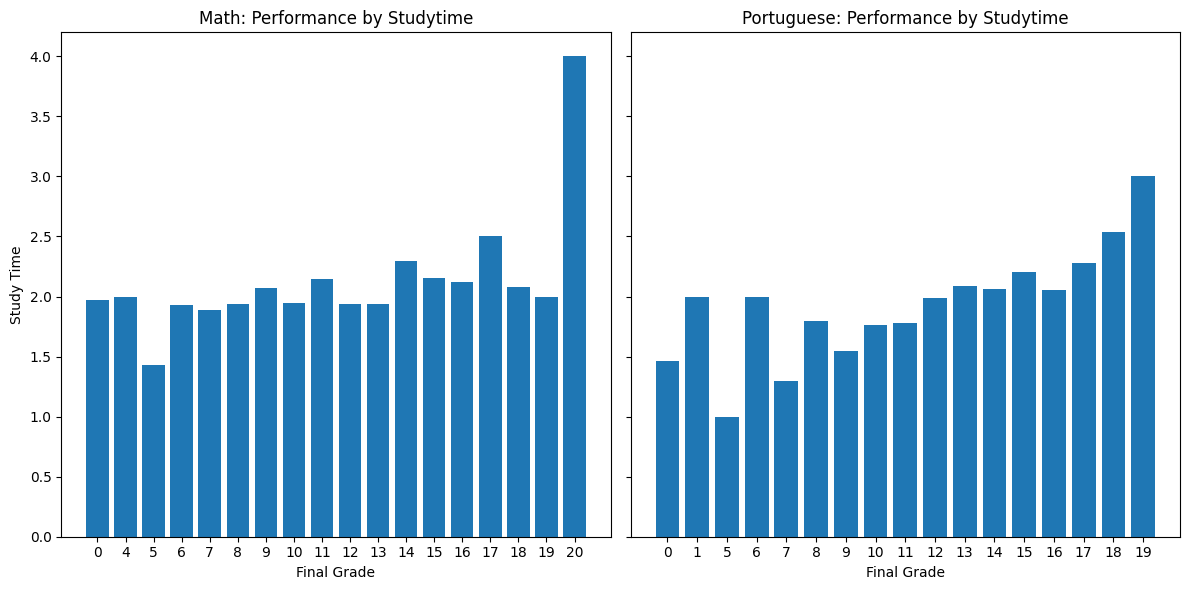

In [57]:
# create barplots for final grade by studytime using subplots code for both Maths and Portuguese

# Grouped data
studytime_math = math_df.groupby('final_grade')['studytime'].mean()
studytime_port = port_df.groupby('final_grade')['studytime'].mean()

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot math_df
axes[0].bar(
    studytime_math.index.astype(str),
    studytime_math.to_numpy()
)
axes[0].set_xlabel('Final Grade')
axes[0].set_ylabel('Study Time')
axes[0].set_title('Math: Performance by Studytime')

# Plot port_df
axes[1].bar(
    studytime_port.index.astype(str),
    studytime_port.to_numpy()
)
axes[1].set_xlabel('Final Grade')
axes[1].set_title('Portuguese: Performance by Studytime')

# Adjust layout
plt.tight_layout()
plt.show()


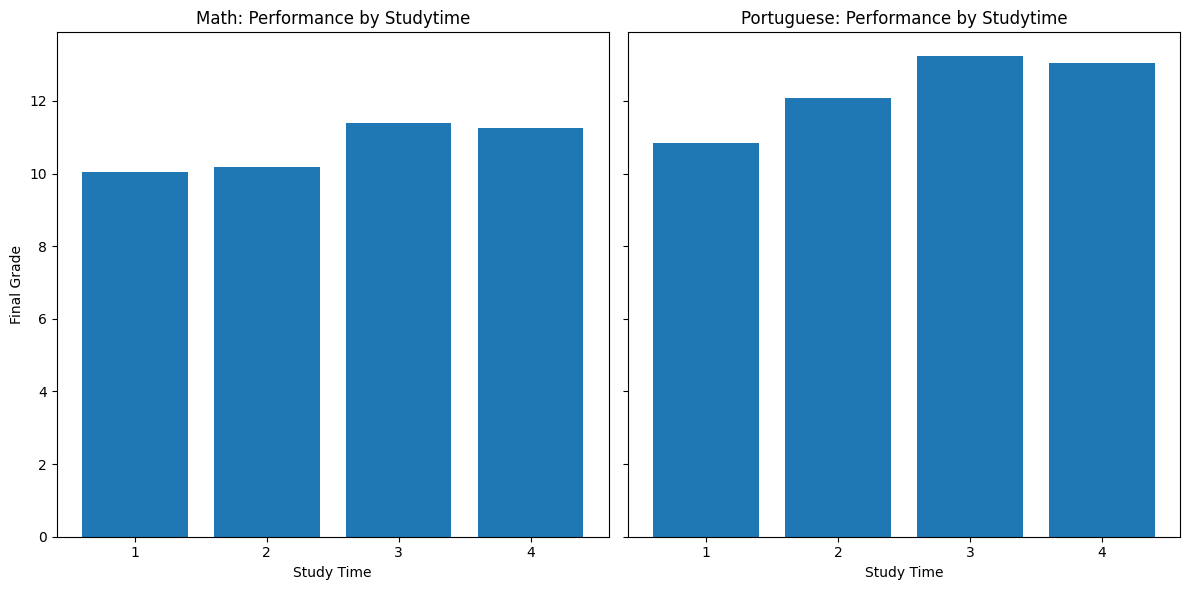

In [ ]:
# create barplots for final grade by studytime using subplots code for both Maths and Portuguese

# Grouped data
studytime_math = math_df.groupby('studytime')['final_grade'].mean()
studytime_port = port_df.groupby('studytime')['final_grade'].mean()

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot math_df
axes[0].bar(
    studytime_math.index.astype(str),
    studytime_math.to_numpy()
)
axes[0].set_xlabel('Study Time')
axes[0].set_ylabel('Final Grade')
axes[0].set_title('Math: Performance by Studytime')

# Plot port_df
axes[1].bar(
    studytime_port.index.astype(str),
    studytime_port.to_numpy()
)
axes[1].set_xlabel('Study Time')
axes[1].set_title('Portuguese: Performance by Studytime')

# Adjust layout
plt.tight_layout()
plt.show()

# final grade (numeric: from 0 to 20, output target)
# studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)


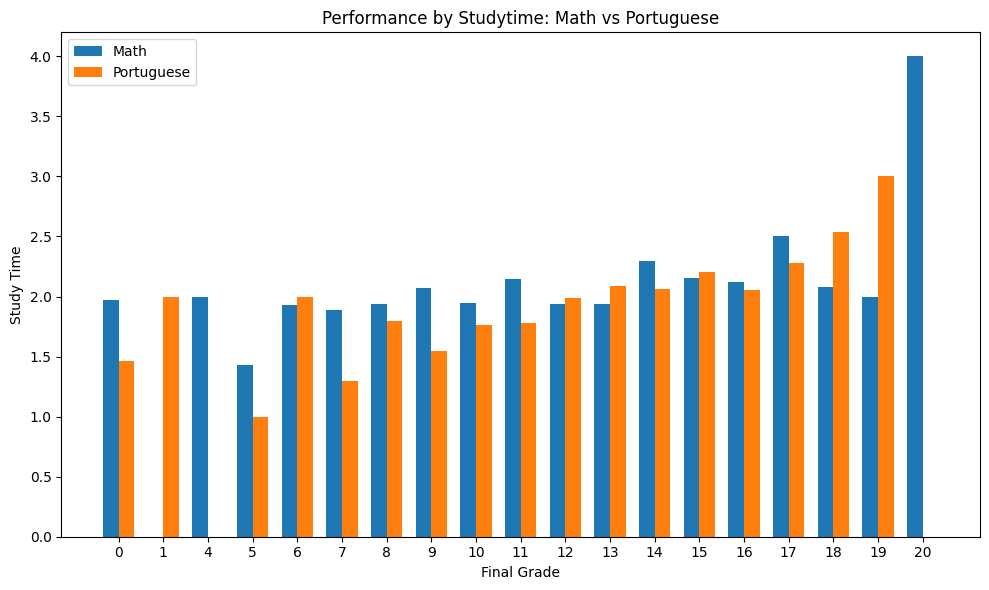

In [59]:
# simplified code for the above where they are stacked next to each other in the same plot

# Grouped data
studytime_math = math_df.groupby('final_grade')['studytime'].mean()
studytime_port = port_df.groupby('final_grade')['studytime'].mean()

# Ensure both have the same index order
grades = sorted(set(studytime_math.index) | set(studytime_port.index))

# Convert to arrays aligned by grade
math_values = [studytime_math.get(g, 0) for g in grades]
port_values = [studytime_port.get(g, 0) for g in grades]

# X positions
x = np.arange(len(grades))
width = 0.35  # width of each bar

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, math_values, width, label='Math')
plt.bar(x + width/2, port_values, width, label='Portuguese')

plt.xlabel('Final Grade')
plt.ylabel('Study Time')
plt.title('Performance by Studytime: Math vs Portuguese')
plt.xticks(x, [str(g) for g in grades])  
plt.legend()

plt.tight_layout()
plt.show()


### 2. Does attendance affect performance?

In [60]:
# group final grade by number of absences
print("Number of Absences for Maths:")
display(math_df.groupby('final_grade')['absences'].median())

print("Number of Absences for Portuguese:")
display(port_df.groupby('final_grade')['absences'].median())

Number of Absences for Maths:


final_grade
0      0.0
4     22.0
5     14.0
6      6.0
7      5.0
8      6.5
9      6.5
10     4.0
11     4.0
12     2.0
13     6.0
14     4.0
15     2.0
16     2.0
17     1.0
18     3.0
19     5.0
20     4.0
Name: absences, dtype: float64

Number of Absences for Portuguese:


final_grade
0      0.0
1      0.0
5     12.0
6      4.0
7      5.5
8      4.0
9      4.0
10     4.0
11     4.0
12     2.0
13     1.5
14     2.0
15     2.0
16     0.5
17     2.0
18     0.0
19     2.0
Name: absences, dtype: float64

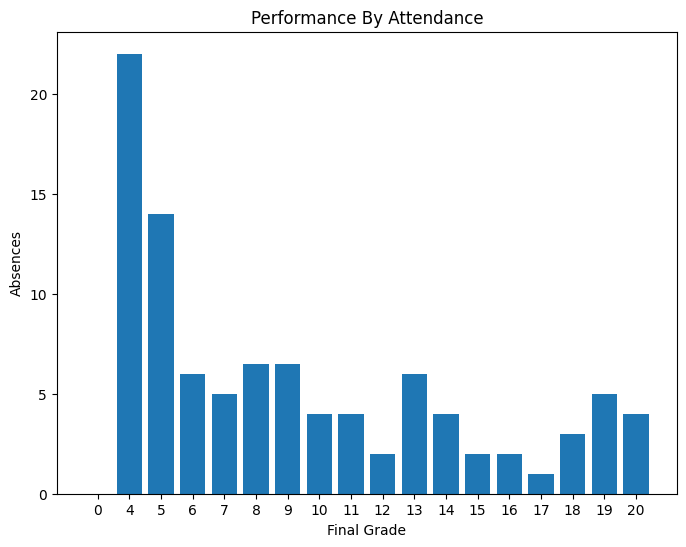

In [62]:
attendance_by_performance = math_df.groupby('final_grade')['absences'].median()

plt.figure(figsize=(8, 6))

plt.bar(
    attendance_by_performance.index.astype(str),
    attendance_by_performance.to_numpy() 
)

plt.xlabel('Final Grade')
plt.ylabel('Absences')
plt.title('Performance By Attendance')

plt.show()

### 3. Does previous academic performance predict final grades?

In [63]:
display(math_df[['first_grade', 'second_grade', 'final_grade']].corr())
display(port_df[['first_grade', 'second_grade', 'final_grade']].corr())

,first_grade,second_grade,final_grade
first_grade,1.000000,0.852118,0.801468
second_grade,0.852118,1.000000,0.904868
final_grade,0.801468,0.904868,1.000000


,first_grade,second_grade,final_grade
first_grade,1.000000,0.864982,0.826387
second_grade,0.864982,1.000000,0.918548
final_grade,0.826387,0.918548,1.000000


#### Maths - Second Period Grade

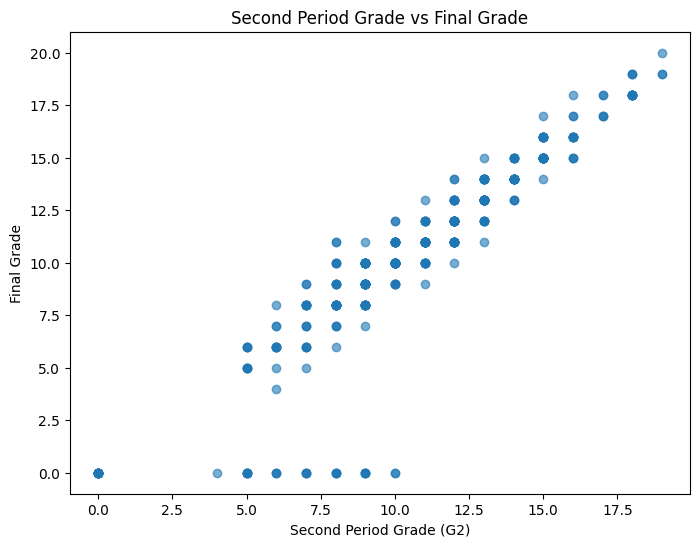

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(math_df['second_grade'], math_df['final_grade'], alpha=0.6)

plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade')
plt.title('Second Period Grade vs Final Grade')

plt.show()

#### Portuguese

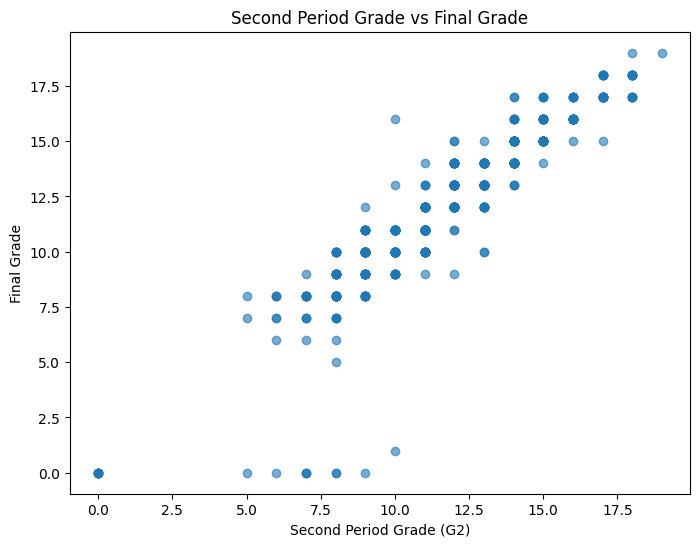

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(port_df['second_grade'], port_df['final_grade'], alpha=0.6)

plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade')
plt.title('Second Period Grade vs Final Grade')

plt.show()

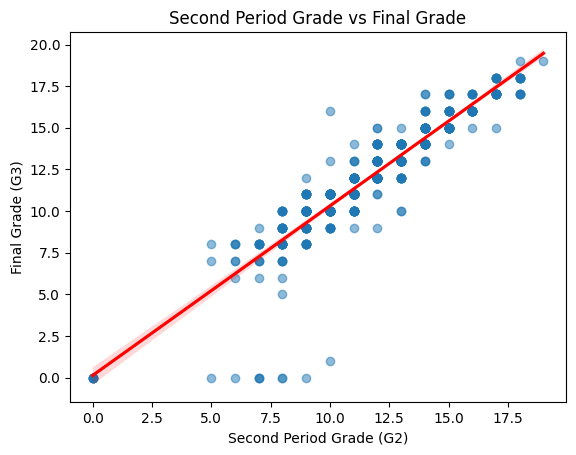

In [67]:
# putting regression lines on the plots
sns.regplot(
    data=port_df,
    x='second_grade',
    y='final_grade',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade (G3)')
plt.title('Second Period Grade vs Final Grade')

plt.show()

#### Maths - First Period Grade

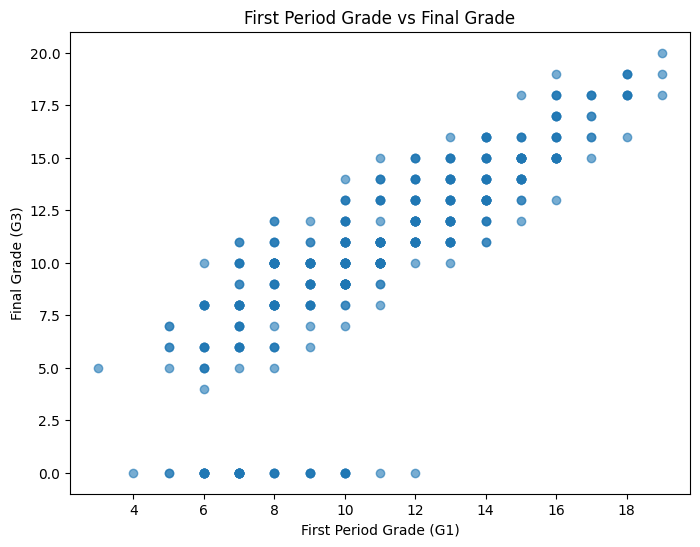

In [69]:
plt.figure(figsize=(8, 6))

plt.scatter(math_df['first_grade'], math_df['final_grade'], alpha=0.6)

plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.title('First Period Grade vs Final Grade')

plt.show()

#### Portuguese

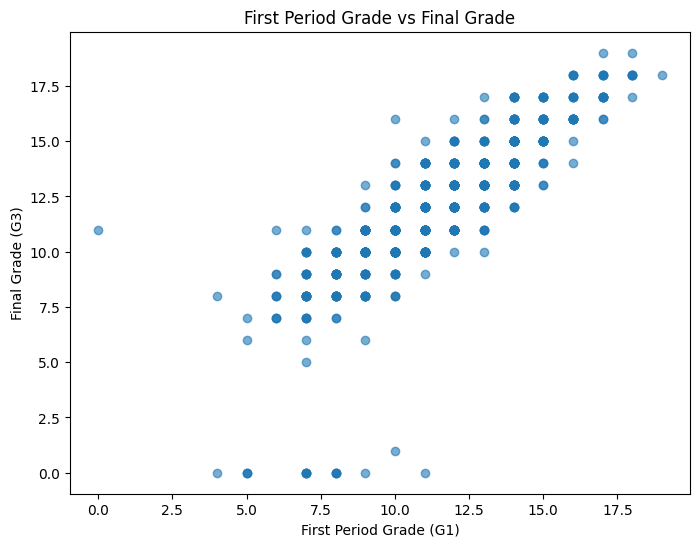

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(port_df['first_grade'], port_df['final_grade'], alpha=0.6)

plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.title('First Period Grade vs Final Grade')

plt.show()

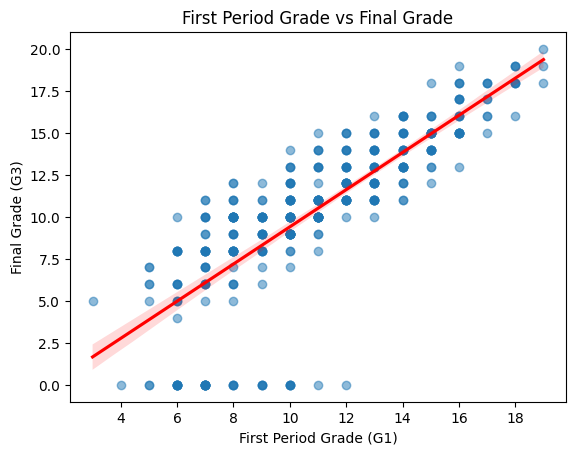

In [70]:
# putting regression lines on the plots
sns.regplot(
    data=math_df,
    x='first_grade',
    y='final_grade',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.title('First Period Grade vs Final Grade')

plt.show()

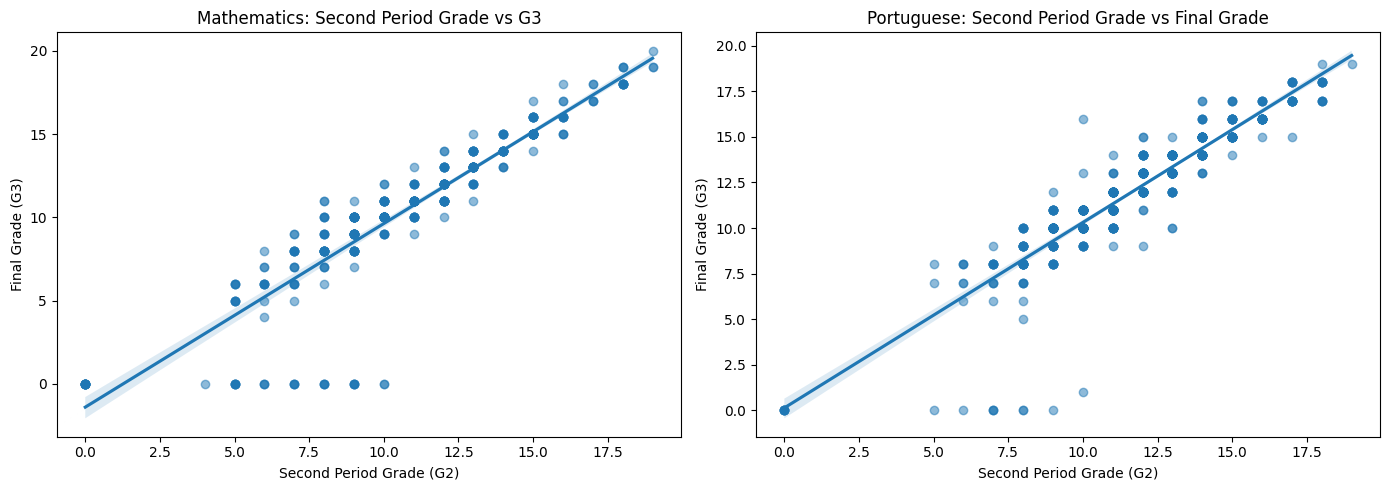

In [73]:
# using subplots for the above code
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=math_df,
    x='second_grade',
    y='final_grade',
    ax=axes[0],
    scatter_kws={'alpha': 0.5}
)

axes[0].set_title('Mathematics: Second Period Grade vs G3')
axes[0].set_xlabel('Second Period Grade (G2)')
axes[0].set_ylabel('Final Grade (G3)')


sns.regplot(
    data=port_df,
    x='second_grade',
    y='final_grade',
    ax=axes[1],
    scatter_kws={'alpha': 0.5}
)

axes[1].set_title('Portuguese: Second Period Grade vs Final Grade')
axes[1].set_xlabel('Second Period Grade (G2)')
axes[1].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.show()

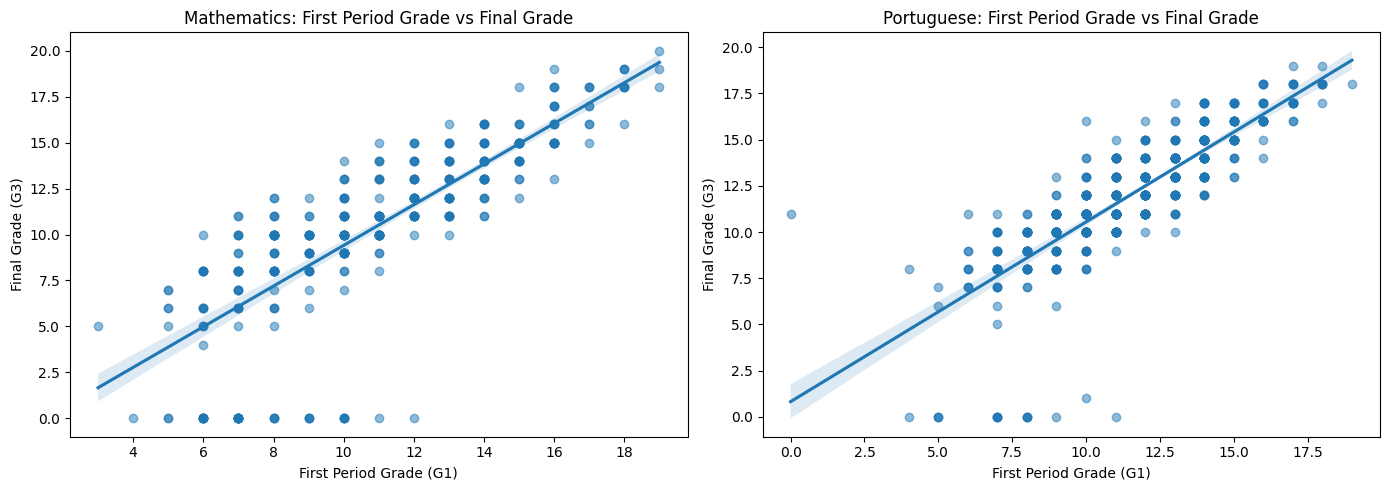

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=math_df,
    x='first_grade',
    y='final_grade',
    ax=axes[0],
    scatter_kws={'alpha': 0.5}
)

axes[0].set_title('Mathematics: First Period Grade vs Final Grade')
axes[0].set_xlabel('First Period Grade (G1)')
axes[0].set_ylabel('Final Grade (G3)')


sns.regplot(
    data=port_df,
    x='first_grade',
    y='final_grade',
    ax=axes[1],
    scatter_kws={'alpha': 0.5}
)

axes[1].set_title('Portuguese: First Period Grade vs Final Grade')
axes[1].set_xlabel('First Period Grade (G1)')
axes[1].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.show()